In [1]:
from google.colab import files
uploaded = files.upload()

Saving q2_customers.csv to q2_customers.csv


In [ ]:
# Q2: Unsupervised Learning — Customer Segmentation

This notebook performs customer segmentation using K-Means clustering.

Since there is no target variable, unsupervised learning is used to group similar customers based on their behaviour.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (500, 6)

Data types:
 age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


In [ ]:
## 1. Data Preparation

The dataset has been loaded and inspected. It contains customer-related numerical features such as spending, visit frequency, and purchasing behaviour.

These features will be used to group customers into clusters using K-Means clustering.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [6]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

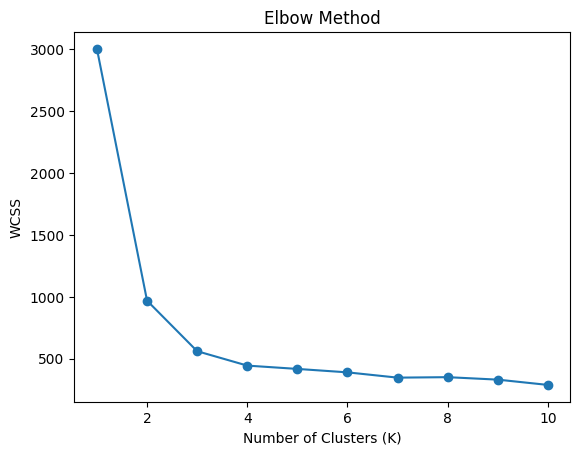

In [7]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [ ]:
### Elbow Method Interpretation

The optimal number of clusters is chosen at the point where the curve starts to flatten (the elbow point).

In [ ]:
### Elbow Method Interpretation

From the graph, the WCSS decreases sharply from K=1 to K=3, and then the curve starts to flatten.

This indicates that the optimal number of clusters is 3, as adding more clusters after this point does not significantly reduce the WCSS.

Therefore, K = 3 is chosen as the optimal number of clusters.

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [10]:
df['cluster'] = clusters

In [11]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


In [ ]:
### Cluster Interpretation

The cluster centroids are shown in scaled form, so positive values indicate above-average behaviour and negative values indicate below-average behaviour.

- **Cluster 0** represents younger customers who visit frequently but spend less, buy fewer categories, and have smaller basket sizes.
- **Cluster 1** represents older, high-value customers who visit less often but spend more, buy more categories, and have larger basket sizes.
- **Cluster 2** represents average customers whose behaviour is close to the overall dataset average across most features.

These segments could help the business design different marketing strategies for each customer group.

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [13]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.83560354 0.05568764]


In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

loadings

,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


In [ ]:
### PCA Interpretation

PCA reduces the dataset into two principal components, PC1 and PC2, while keeping as much information as possible.

The explained variance ratio shows how much variance is captured by each component. The feature loadings show which original variables contribute most strongly to PC1 and PC2.

Features with larger absolute loading values have a stronger influence on that principal component.

In [15]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

pca_df['cluster'] = clusters

pca_df.head()

,PC1,PC2,cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


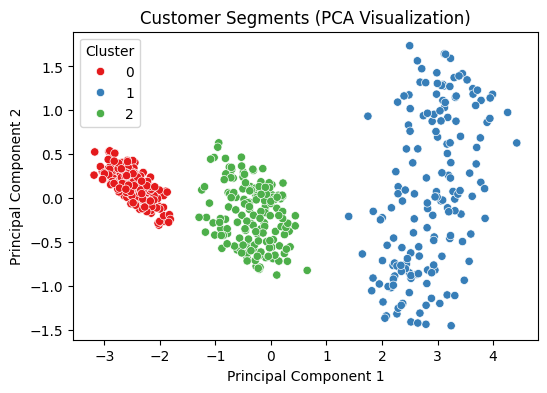

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1'
)

plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Cluster')
plt.show()

In [ ]:
### Cluster Visualisation

The clusters are visualised using the first two principal components obtained from PCA.

Each point represents a customer, and colours indicate different clusters. The plot shows how customers are grouped into distinct segments based on their behaviour.

The separation between clusters indicates that the K-Means algorithm has successfully identified meaningful customer groups.